# Problem 1 Question 2.2 - CNN -  EfficientNetB0 - 64x64x3
ealyer it was resized to 224x224 for the comparison between B0 and B5

Mounted at /content/drive
Models will be saved to: /content/drive/MyDrive/models


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


dataset_infos.json:   0%|          | 0.00/943 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/88.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/27000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 27000
    })
})
Image shape: (27000, 64, 64, 3)
Label shape: (27000,)
Dataset shapes:
Train images: (17280, 64, 64, 3)
Train labels: (17280,)
Validation images: (4320, 64, 64, 3)
Validation labels: (4320,)
Test images: (5400, 64, 64, 3)
Test labels: (5400,)


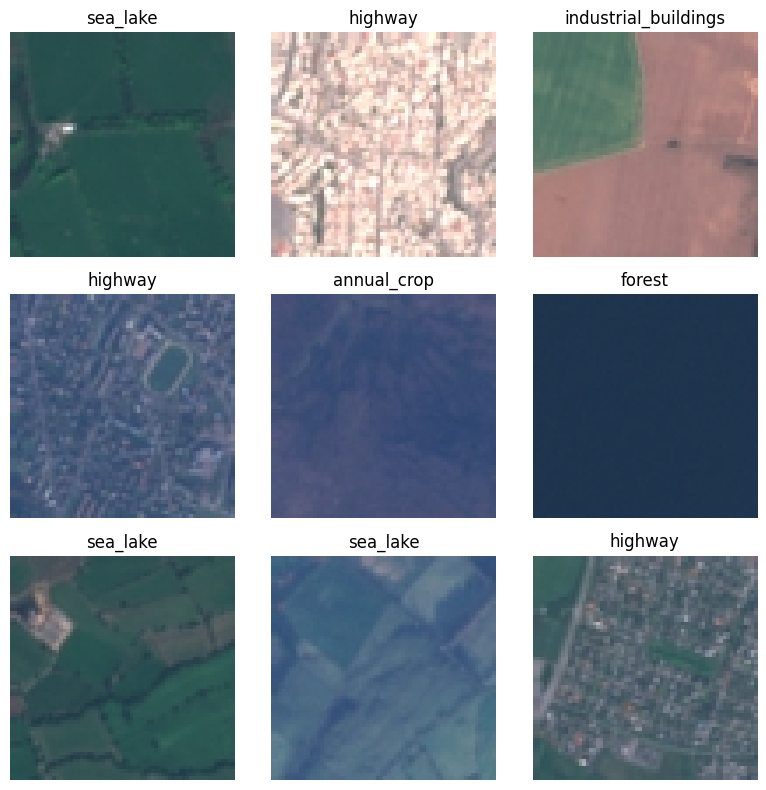

After preprocessing:
Train: (17280, 64, 64, 3)
Validation: (4320, 64, 64, 3)
Test: (5400, 64, 64, 3)

BUILDING BASELINE EFFICIENTNETB0 MODEL
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model loaded - all layers frozen


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 2, 2, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_vector (Dense)          │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,829 (16.08 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 4,049,571 (15.45 MB)


Training baseline model...
Epoch 1/50
539/540 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7343 - loss: 0.7845
Epoch 1: val_loss improved from inf to 0.34265, saving model to /content/drive/MyDrive/models/EFFICIENTNETB0_baseline5.keras
540/540 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - accuracy: 0.7346 - loss: 0.7837 - val_accuracy: 0.8826 - val_loss: 0.3426
Epoch 2/50
537/540 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8666 - loss: 0.3952
Epoch 2: val_loss improved from 0.34265 to 0.27534, saving model to /content/drive/MyDrive/models/EFFICIENTNETB0_baseline5.keras
540/540 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.8666 - loss: 0.3951 - val_accuracy: 0.9042 - val_loss: 0.2753
Epoch 3/50
537/540 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8819 - loss: 0.3508
Epoch 3: val_loss improved from 0.27534 to 0.26823, saving model to /content/drive/MyDrive/models/EFFICIENTNETB0_baseline5.keras
540/540 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.8819 - loss: 0.3508 - val_accuracy:

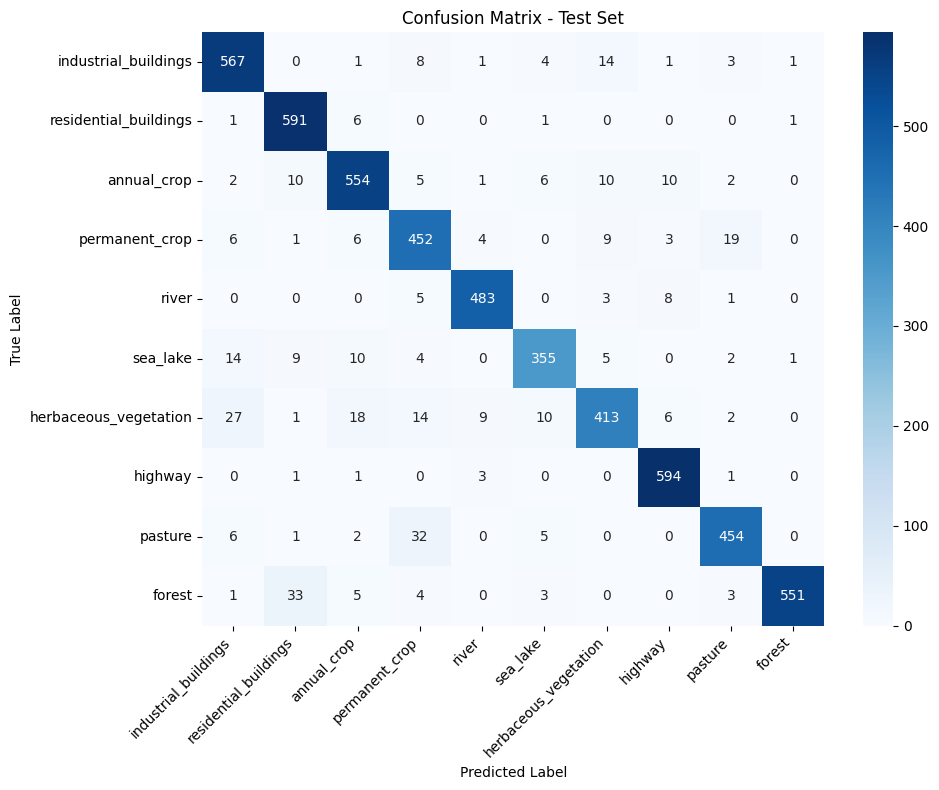

In [ ]:
import tensorflow as tf
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.decomposition import PCA

from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from datasets import load_dataset

from google.colab import drive
import os
import seaborn as sns
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input


# ===== Mount Google Drive =====
drive.mount('/content/drive')
MODEL_DIR = "/content/drive/MyDrive/models"
os.makedirs(MODEL_DIR, exist_ok=True)
print("Models will be saved to:", MODEL_DIR)

# Load data
ds = load_dataset("nielsr/eurosat-demo")
print(ds)

# Convert images and labels to NumPy arrays
X = np.array(
    [np.array(sample["image"], dtype=np.float32) for sample in ds["train"]]
)
y = np.array(
    [sample["label"] for sample in ds["train"]],
    dtype=np.int32
)
print("Image shape:", X.shape)
print("Label shape:", y.shape)


# First split: 80% full train / 20% test
X_full_train, X_test, y_full_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Second split: 80% train / 20% validation from full train
X_train, X_val, y_train, y_val = train_test_split(
    X_full_train,
    y_full_train,
    test_size=0.2,
    stratify=y_full_train,
    random_state=42
)

print(f"Dataset shapes:")
print(f"Train images: {X_train.shape}")
print(f"Train labels: {y_train.shape}")
print(f"Validation images: {X_val.shape}")
print(f"Validation labels: {y_val.shape}")
print(f"Test images: {X_test.shape}")
print(f"Test labels: {y_test.shape}")

class_names = [
    "industrial_buildings", "residential_buildings", "annual_crop",
    "permanent_crop", "river", "sea_lake", "herbaceous_vegetation",
    "highway", "pasture", "forest"
]

# Visualize samples
plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[i].astype(np.uint8))
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# Preprocess data
X_train_processed = preprocess_input(X_train.copy())
X_val_processed = preprocess_input(X_val.copy())
X_test_processed = preprocess_input(X_test.copy())

print("After preprocessing:")
print("Train:", X_train_processed.shape)
print("Validation:", X_val_processed.shape)
print("Test:", X_test_processed.shape)

# ===== MODEL 1: BASELINE EFFICIENTNETB0 =====
print("\n" + "="*60)
print("BUILDING BASELINE EFFICIENTNETB0 MODEL")
print("="*60)

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(64, 64, 3)
)
base_model.trainable = False
print("Base model loaded - all layers frozen")

# Data augmentation
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.05),
        tf.keras.layers.RandomZoom(0.1),
    ],
    name="data_augmentation",
)

# Build classification model
inputs = tf.keras.Input(shape=(64, 64, 3))
x = tf.keras.layers.Resizing(64, 64)(inputs)
x = preprocess_input(x)
x = data_augmentation(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu", name="feature_vector")(x)
x = Dropout(0.3)(x)
outputs = Dense(len(class_names), activation="softmax")(x)

model_baseline = Model(inputs=inputs, outputs=outputs)
model_baseline.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model_baseline.summary()

# Callbacks for baseline
checkpoint_baseline = ModelCheckpoint(
    os.path.join(MODEL_DIR, "EFFICIENTNETB0_baseline5.keras"),
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)
callbacks_baseline = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    checkpoint_baseline
]

# Train baseline
print("\nTraining baseline model...")
history_baseline = model_baseline.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=50,
    batch_size=32,
    callbacks=callbacks_baseline,
    verbose=1
)

# ===== MODEL 2: FINE-TUNED EFFICIENTNETB0 =====
print("\n" + "="*60)
print("FINE-TUNING EFFICIENTNETB0 MODEL")
print("="*60)

# Unfreeze last layers
base_model.trainable = True
frozen_count = 0
for layer in base_model.layers[:-30]:
    layer.trainable = False
    frozen_count += 1

print(f"Frozen layers: {frozen_count}/{len(base_model.layers)}")
print(f"Trainable layers: {len(base_model.layers) - frozen_count}/{len(base_model.layers)}")

# Re-compile for fine-tuning
model_baseline.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Callbacks for fine-tuning
checkpoint_finetune = ModelCheckpoint(
    os.path.join(MODEL_DIR, "EFFICIENTNETB0_finetuned5.keras"),
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)
callbacks_finetune = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    checkpoint_finetune
]

# Train fine-tuned model
print("\nFine-tuning model...")
history_finetune = model_baseline.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=15,
    batch_size=32,
    callbacks=callbacks_finetune,
    verbose=1
)

# ===== EVALUATION ON TEST SET =====
print("\n" + "="*60)
print("EVALUATING ON TEST SET")
print("="*60)

y_pred_probs = model_baseline.predict(X_test_processed)
y_pred = np.argmax(y_pred_probs, axis=1)

test_loss, test_acc = model_baseline.evaluate(X_test_processed, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Classification report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



# Problem 1 Question 2.2 - CNN -  EfficientNetB5 224x224x3

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Models will be saved to: /content/drive/MyDrive/models
DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 27000
    })
})
Image shape: (27000, 64, 64, 3)
Label shape: (27000,)
Dataset shapes:
Train images: (17280, 64, 64, 3)
Train labels: (17280,)
Validation images: (4320, 64, 64, 3)
Validation labels: (4320,)
Test images: (5400, 64, 64, 3)
Test labels: (5400,)


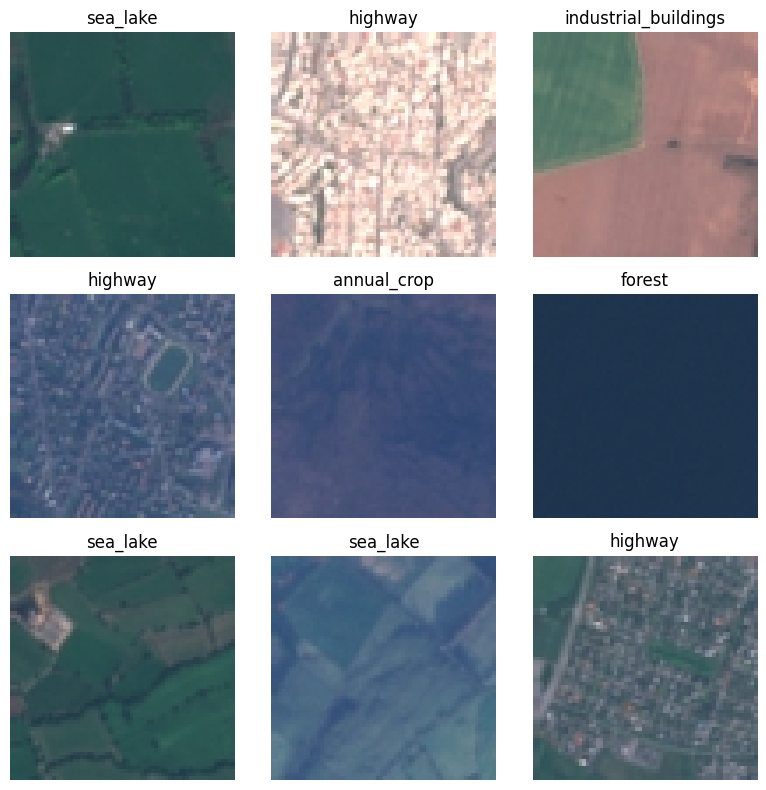

After preprocessing:
Train: (17280, 64, 64, 3)
Validation: (4320, 64, 64, 3)
Test: (5400, 64, 64, 3)

BUILDING BASELINE EFFICIENTNETB5 MODEL
115263384/115263384 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
Base model loaded - all layers frozen


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_2 (Resizing)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb5 (Functional)     │ (None, 7, 7, 2048)     │    28,513,527 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_vector (Dense)          │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,777,089 (109.78 MB)

 Trainable params: 263,562 (1.01 MB)

 Non-trainable params: 28,513,527 (108.77 MB)


Training baseline model...
Epoch 1/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.7756 - loss: 0.6858
Epoch 1: val_loss improved from inf to 0.24538, saving model to /content/drive/MyDrive/models/EFFICIENTNETB5_baseline.keras
540/540 ━━━━━━━━━━━━━━━━━━━━ 65s 82ms/step - accuracy: 0.7757 - loss: 0.6854 - val_accuracy: 0.9181 - val_loss: 0.2454
Epoch 2/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9059 - loss: 0.2889
Epoch 2: val_loss improved from 0.24538 to 0.22454, saving model to /content/drive/MyDrive/models/EFFICIENTNETB5_baseline.keras
540/540 ━━━━━━━━━━━━━━━━━━━━ 37s 69ms/step - accuracy: 0.9059 - loss: 0.2889 - val_accuracy: 0.9262 - val_loss: 0.2245
Epoch 3/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9130 - loss: 0.2618
Epoch 3: val_loss improved from 0.22454 to 0.20859, saving model to /content/drive/MyDrive/models/EFFICIENTNETB5_baseline.keras
540/540 ━━━━━━━━━━━━━━━━━━━━ 37s 69ms/step - accuracy: 0.9130 - loss: 0.2618 - val_accuracy: 

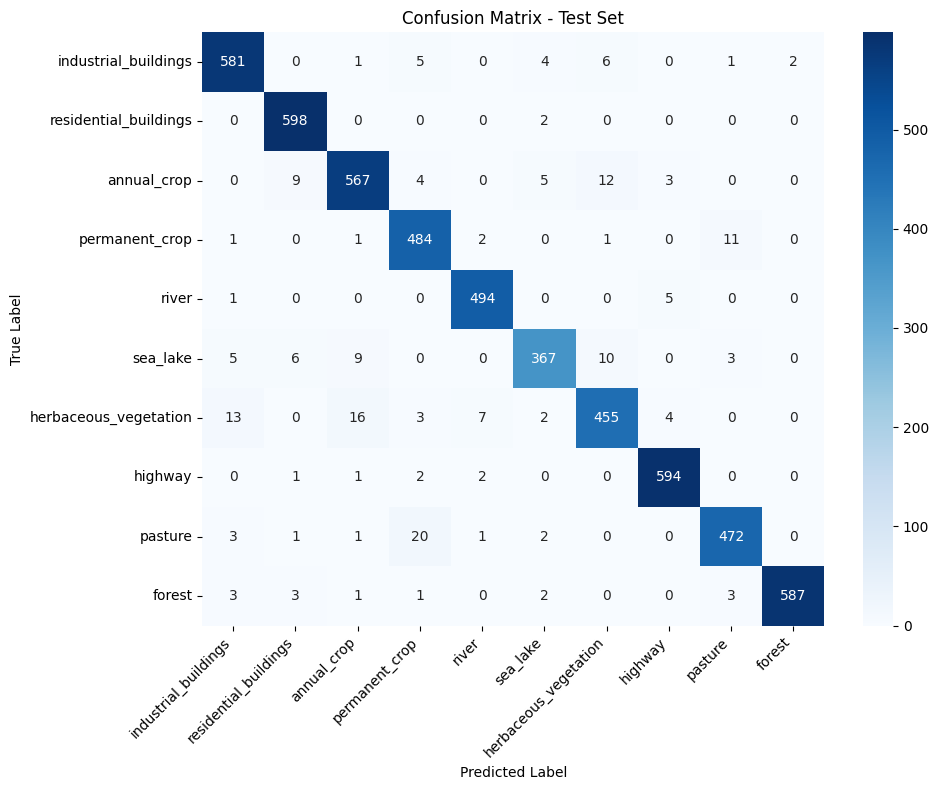

In [ ]:
import tensorflow as tf
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.decomposition import PCA

from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from datasets import load_dataset

from google.colab import drive
import os
import seaborn as sns
from tensorflow.keras.applications import EfficientNetB5
from tensorflow.keras.applications.efficientnet import preprocess_input


# ===== Mount Google Drive =====
drive.mount('/content/drive')
MODEL_DIR = "/content/drive/MyDrive/models"
os.makedirs(MODEL_DIR, exist_ok=True)
print("Models will be saved to:", MODEL_DIR)

# Load data
ds = load_dataset("nielsr/eurosat-demo")
print(ds)

# Convert images and labels to NumPy arrays
X = np.array(
    [np.array(sample["image"], dtype=np.float32) for sample in ds["train"]]
)
y = np.array(
    [sample["label"] for sample in ds["train"]],
    dtype=np.int32
)
print("Image shape:", X.shape)
print("Label shape:", y.shape)


# First split: 80% full train / 20% test
X_full_train, X_test, y_full_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Second split: 80% train / 20% validation from full train
X_train, X_val, y_train, y_val = train_test_split(
    X_full_train,
    y_full_train,
    test_size=0.2,
    stratify=y_full_train,
    random_state=42
)

print(f"Dataset shapes:")
print(f"Train images: {X_train.shape}")
print(f"Train labels: {y_train.shape}")
print(f"Validation images: {X_val.shape}")
print(f"Validation labels: {y_val.shape}")
print(f"Test images: {X_test.shape}")
print(f"Test labels: {y_test.shape}")

class_names = [
    "industrial_buildings", "residential_buildings", "annual_crop",
    "permanent_crop", "river", "sea_lake", "herbaceous_vegetation",
    "highway", "pasture", "forest"
]

# Visualize samples
plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[i].astype(np.uint8))
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# Preprocess data
X_train_processed = preprocess_input(X_train.copy())
X_val_processed = preprocess_input(X_val.copy())
X_test_processed = preprocess_input(X_test.copy())

print("After preprocessing:")
print("Train:", X_train_processed.shape)
print("Validation:", X_val_processed.shape)
print("Test:", X_test_processed.shape)

# ===== MODEL 1: BASELINE EFFICIENTNETB5 =====
print("\n" + "="*60)
print("BUILDING BASELINE EFFICIENTNETB5 MODEL")
print("="*60)

base_model = EfficientNetB5(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False
print("Base model loaded - all layers frozen")

# Data augmentation
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.05),
        tf.keras.layers.RandomZoom(0.1),
    ],
    name="data_augmentation",
)

# Build classification model
inputs = tf.keras.Input(shape=(64, 64, 3))
x = tf.keras.layers.Resizing(224, 224)(inputs)
x = preprocess_input(x)
x = data_augmentation(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu", name="feature_vector")(x)
x = Dropout(0.3)(x)
outputs = Dense(len(class_names), activation="softmax")(x)

model_baseline = Model(inputs=inputs, outputs=outputs)
model_baseline.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model_baseline.summary()

# Callbacks for baseline
checkpoint_baseline = ModelCheckpoint(
    os.path.join(MODEL_DIR, "EFFICIENTNETB5_baseline.keras"),
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)
callbacks_baseline = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    checkpoint_baseline
]

# Train baseline
print("\nTraining baseline model...")
history_baseline = model_baseline.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=50,
    batch_size=32,
    callbacks=callbacks_baseline,
    verbose=1
)

# ===== MODEL 2: FINE-TUNED EFFICIENTNET=====
print("\n" + "="*60)
print("FINE-TUNING EFFICIENTNET MODEL")
print("="*60)

# Unfreeze last layers
base_model.trainable = True
frozen_count = 0
for layer in base_model.layers[:-30]:
    layer.trainable = False
    frozen_count += 1

print(f"Frozen layers: {frozen_count}/{len(base_model.layers)}")
print(f"Trainable layers: {len(base_model.layers) - frozen_count}/{len(base_model.layers)}")

# Re-compile for fine-tuning
model_baseline.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Callbacks for fine-tuning
checkpoint_finetune = ModelCheckpoint(
    os.path.join(MODEL_DIR, "EFFICIENTNETB5_finetuned.keras"),
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)
callbacks_finetune = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    checkpoint_finetune
]

# Train fine-tuned model
print("\nFine-tuning model...")
history_finetune = model_baseline.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=15,
    batch_size=32,
    callbacks=callbacks_finetune,
    verbose=1
)

# ===== EVALUATION ON TEST SET =====
print("\n" + "="*60)
print("EVALUATING ON TEST SET")
print("="*60)

y_pred_probs = model_baseline.predict(X_test_processed)
y_pred = np.argmax(y_pred_probs, axis=1)

test_loss, test_acc = model_baseline.evaluate(X_test_processed, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Classification report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

